## The project Goal

We want to answer:

"Can we predict the price of a house from its area?"

The mathematical model is:

$$ \hat y = wx+b $$

where:

\(x\) = house area
\(y\) = actual house price
\(w\) = weight/slope
\(b\) = bias/intercept
\(\hat y\) = predicted price

Input -

House area in square feet.

Output -

House price.

Loading the libraries

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load data

In [168]:
df = pd.read_csv('Data/Housing.csv')
df.head(10) # cheacking if the data is loaded correctly.

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [169]:
df.shape # checking the shape of the data
df.info() # checking the information of the data
df.describe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


<bound method NDFrame.describe of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       

## Inspect the data

In [170]:
# Missing values
df.isnull().sum() # checking the missing values in the data

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [171]:
df.duplicated().sum() # checking the duplicated values in the data

np.int64(0)

In [172]:
df.dtypes # checking the data types of the data

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

## Start building model with just one feature

In [173]:
x = df['area'] # Loading the area column as the independent variable
y = df['price'] # Loading the price column as the dependent variable

Plotting the graph

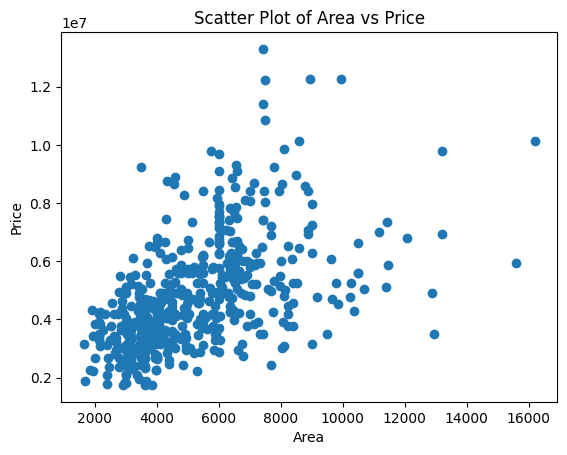

In [174]:
plt.scatter(x, y) # plotting the scatter plot of the data
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Scatter Plot of Area vs Price')
plt.show()

The plotted graph shows that there some linear relation between Area and a Price, so we can run linear regression algo. 
This phase is matter most as we have to know if the algo is suitable for the data.

### Now as the data inspaction done we can start the algo.

Preparing the X and Y
The feature and target.

In [175]:
X = df[[ 'area' ]].values
y = df['price'].values
print(X.shape) # checking the shape of the independent variable
print(y.shape) # checking the shape of the dependent variable

(545, 1)
(545,)


### Training and Test data split
If you train and test on the same data, the model can "memorize" the answers and look great — but fail on new data. 
So we have to split the data into two parts.
Note - we have to split in a way so that we get same split every time. Other wise we will get different results.

We will split into 80/20
```
80% → training
20% → testing

```

In [176]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Here the random_state helps to get the same split everytime.

For now we can pass the Standardization for one feature.

In [177]:
X_train.shape # checking the shape of the training data

(436, 1)

In [178]:
X_test.shape # checking the shape of the testing data

(109, 1)

In [179]:
y_train.shape # checking the shape of the training data

(436,)

In [180]:
y_test.shape # checking the shape of the testing data

(109,)

The data sets splited in right portion. 80/20
and X for Y is same dimetion.

## Build Linear Regression FROM SCRATCH

We will use linear regression as we already know
So starting with initial parameters.

In [181]:
# w = 0
# b = 0

Define predictions:

In [182]:
def predict(X,w,b):
    return w*X + b

Define MSE:
This function will calculate the error in prediction.
Hence error function.

In [183]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

Now gradient descent.

$$ J(w,b)=1/n​∑(\hat{y}​−y)^2 $$

the gradients are:

$$ ∂J/∂w​=2/n​∑X(\hat{y}​−y) $$

and 

$$ ∂J/∂b​=2/n​∑(\hat{y}​−y) $$

than

$$ w:=w−α(∂J/∂w)​ $$

$$ b:=b−α(∂J/∂b)​ $$

Alpha is a learning rate.

Now we have to implement this in python. and train a model.

In [184]:
def train_linear_regression(X,y, learning_rate, epochs): # epochs is the number of iterations
    w, b = 0.0, 0.0 # w=0.0 and b=0.0 are the initial values of the weights and bias
    

    n = len(X) # number of data points
    X_mean, X_std = X.mean(), X.std() # calculating the mean and standard deviation of the independent variable
    X = (X - X_mean) / X_std    # normalizing the independent variable

    # normalize target for numerical stability
    y_mean = y.mean()
    y_std = y.std()
    y_norm = (y - y_mean) / y_std

    for epoch in range(epochs):

        y_pred = w * X + b # predicting the values using the current weights and bias

        loss = np.mean((y - y_pred) ** 2)
        loss_history.append(loss)

        dw = (2/n) * np.sum( X * (y_pred - y) ) # calculating the gradient of the weights
        db = (2/n) * np.sum( y_pred - y ) # calculating the gradient of the bias
        

        w = w - learning_rate * dw # updating the weights
        b = b - learning_rate * db # updating the bias

        if np.isnan(w) or np.isnan(b):
            print(f"Diverged at epoch {epoch}")
            break

    return w,b # returning the final values of the weights and bias

In [185]:
loss_history = [] # Storing loss history during the training

Last thing is to train it.

In [186]:
w, b = train_linear_regression(X_train.flatten(), y_train, learning_rate=0.0001, epochs=1000) # training the model using the training data

In [187]:
print(f'Weight: {w}, Bias: {b}') # printing the final values of the weights and bias

Weight: 169930.85201050979, Bias: 853225.7518355642


Run the model.

In [188]:
y_test_predict = predict(X_test.flatten(), w, b)
print(y_test_predict) # predicting the values using the testing data
    

[1.00344525e+09 1.10540376e+09 6.87373868e+08 8.50507486e+08
 6.73779400e+08 1.14278855e+09 1.44866408e+09 8.48808177e+08
 5.51429186e+08 4.59666526e+08 1.45885994e+09 6.69361198e+08
 6.32995995e+08 5.27638867e+08 6.75478708e+08 6.17702219e+08
 3.40714930e+08 1.02043834e+09 9.94948710e+08 1.02043834e+09
 8.53906103e+08 1.16063129e+09 6.20930905e+08 6.46590463e+08
 1.40278275e+09 1.69336451e+09 5.25939558e+08 5.10645782e+08
 2.24394047e+09 5.10645782e+08 6.80576634e+08 5.31037484e+08
 1.02043834e+09 1.12494581e+09 8.12273044e+08 7.82535145e+08
 7.90351964e+08 5.41233335e+08 5.92212591e+08 4.74450510e+08
 1.35690142e+09 6.17702219e+08 1.09180930e+09 7.14562804e+08
 1.14788648e+09 1.00089629e+09 1.02043834e+09 7.89332379e+08
 1.36879658e+09 5.10645782e+08 1.27108634e+09 5.10645782e+08
 1.32121595e+09 7.65542060e+08 6.19401527e+08 4.95352005e+08
 9.77955625e+08 4.08687271e+08 1.09690722e+09 6.46590463e+08
 5.41233335e+08 3.63655595e+08 1.09520791e+09 8.43710252e+08
 9.11682593e+08 6.397932

Now it's time to calculate the error my boy let's gooo.

In [189]:
error = mse(y_test, y_test_predict) # calculating the mean squared error of the model
print(f'Mean Squared Error: {error}') # printing the mean squared error of the model

Mean Squared Error: 8.724008430248873e+17


Okay the error is too high bro, but why? well remember we are onlt using one feature for training this linear model.

Now we are going to watch gradient descent learn.
Than plot it.

In [190]:
print(loss_history)

[np.float64(25234792406487.613), np.float64(25225581306199.72), np.float64(25216373889983.496), np.float64(25207170156365.465), np.float64(25197970103872.73), np.float64(25188773731032.992), np.float64(25179581036374.527), np.float64(25170392018426.22), np.float64(25161206675717.535), np.float64(25152025006778.527), np.float64(25142847010139.816), np.float64(25133672684332.64), np.float64(25124502027888.824), np.float64(25115335039340.758), np.float64(25106171717221.42), np.float64(25097012060064.414), np.float64(25087856066403.87), np.float64(25078703734774.56), np.float64(25069555063711.797), np.float64(25060410051751.523), np.float64(25051268697430.23), np.float64(25042130999285.004), np.float64(25032996955853.543), np.float64(25023866565674.08), np.float64(25014739827285.477), np.float64(25005616739227.164), np.float64(24996497300039.14), np.float64(24987381508262.027), np.float64(24978269362436.984), np.float64(24969160861105.79), np.float64(24960056002810.79), np.float64(24950954

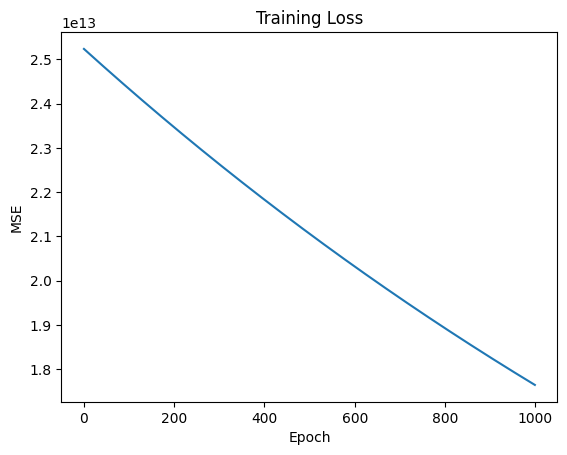

In [191]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training Loss")
plt.show()

From the graph you can see the loss going down or evey epoch.

Now it's time to predict the output.

First let's plot the original data. To see the difference.

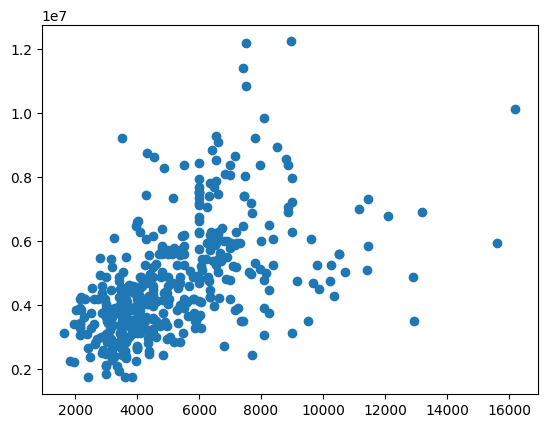

In [192]:
plt.scatter(X_train, y_train)

In [193]:
y_train_pred = predict(X_train.flatten(), w, b)

Plotting the prediction data.

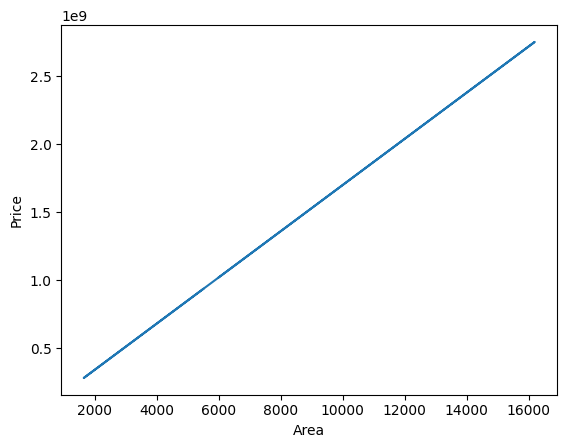

In [194]:
plt.plot(X_train, y_train_pred)
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

For every X the predicted Y is on the line.
This is done on train data but we already have done on test data which will also have the same result (every X in the test have Y redicted on this line)

We calculated the error.

Now let's see how badly our model works in the sense how much the difference are in the actual and predicted value.

In [195]:
results = pd.DataFrame({
    "Actual":y_test,
    "Prediction":y_test_predict })

For the error what we did was calculated the difference of this two data and sqaured them than took avarage of the values.

But here we are invetigating the model.

In [196]:
results["Error"] = results["Actual"] - results["Prediction"]

print(results.head(10))

    Actual    Prediction         Error
0  4060000  1.003445e+09 -9.993853e+08
1  6650000  1.105404e+09 -1.098754e+09
2  3710000  6.873739e+08 -6.836639e+08
3  6440000  8.505075e+08 -8.440675e+08
4  2800000  6.737794e+08 -6.709794e+08
5  4900000  1.142789e+09 -1.137889e+09
6  5250000  1.448664e+09 -1.443414e+09
7  4543000  8.488082e+08 -8.442652e+08
8  2450000  5.514292e+08 -5.489792e+08
9  3353000  4.596665e+08 -4.563135e+08


In [197]:
results.sort_values("Error").head()

,Actual,Prediction,Error
28,9800000,2.243940e+09,-2.234140e+09
73,6615000,1.785127e+09,-1.778512e+09
25,12250000,1.693365e+09,-1.681115e+09
94,6440000,1.458860e+09,-1.452420e+09
10,10150000,1.458860e+09,-1.448710e+09


In [198]:
results.sort_values("Error").tail()

,Actual,Prediction,Error
57,2100000,4.086873e+08,-4.065873e+08
61,3500000,3.636556e+08,-3.601556e+08
16,2660000,3.407149e+08,-3.380549e+08
90,4340000,3.245715e+08,-3.202315e+08
84,1890000,2.897357e+08,-2.878457e+08


From the inspection we can see the models predicted worst for the house 57.

Our model with one variable in numpy is done.

Now it's time to build the same linear regression model in scikit-learn.
It's a python ML library.
and also the code will be very short.

In [199]:
from sklearn.linear_model import LinearRegression

You will be amazed that how it's easy to create an model in this library.

In [200]:
model = LinearRegression()

model.fit(X_train, y_train) # tha't it the model is ready we just had to give the X and Y

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[425.73]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.512e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[45974.61]


Predict

In [201]:
y_pred = model.predict(X_test)

In [202]:
print(model.coef_) # w given by this model
print(w) # the w given by our numpy model
print(model.intercept_) # b given by this model
print(b) # b given by out numpy model

[425.72984194]
169930.85201050979
2512254.2639593435
853225.7518355642


Now at last we have to train model with multivariable.

for which we just have to make a little change 

instead of X being n X 1 vector it becomes a matrix of n X m

In [203]:
X = df[
    ["area", "bedrooms", "bathrooms", "parking"]
    ].values

y = df["price"].values

In [204]:
print(X.shape)

(545, 4)


In [205]:
def train_with_multiVar(X,y, learning_rate, epochs): # epochs is the number of iterations

    # Initialize weights (one per feature) and bias
    n_samples, n_features = X.shape
    w = np.zeros(n_features)   
    b = 0.0


    loss_history = []


    # Normalize each feature (column-wise mean/std)
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)
    X = (X - X_mean) / X_std

    # normalize target for numerical stability
    y_mean = y.mean()
    y_std = y.std()
    y_norm = (y - y_mean) / y_std

    for epoch in range(epochs):

        y_pred = X @ w + b # predicting the values using the current weights and bias

        loss = np.mean((y_norm - y_pred) ** 2)
        loss_history.append(loss)

        error = y_pred - y_norm    

        dw = (2 / n_samples) * (X.T @ error)  # calculating the gradient of the weights
        db = (2 / n_samples) * np.sum(error) # calculating the gradient of the bias
        

        w = w - learning_rate * dw # updating the weights
        b = b - learning_rate * db # updating the bias

    return w,b # returning the final values of the weights and bias

In [206]:
w, b = train_with_multiVar(X,y, learning_rate=0.0001, epochs=1000)

In [207]:
print(w)
print(b)

[0.09231369 0.06091662 0.0886745  0.06409484]
3.87891146318064e-17


In [208]:
def predic_multiVar(X,w,b):
    return X @ w + b

pr = predic_multiVar(X,w,b)
print(pr)


[ 685.51682202  827.92135616  919.9326907   692.96601245  685.42814752
  692.92967551  792.68938272 1496.05246554  748.20146011  531.22793992
 1218.94038799  554.52004963  605.13981253  323.64713763  720.40691983
  554.34270062  609.75549728  785.154696    425.13128551  593.07811557
  399.19477641  660.99277623  743.46076391  421.37464288  812.8488045
  604.28077042  554.24226884  819.61956229  734.50399698  508.21043279
  690.53315863  646.595479    450.97594189  550.70249037  631.8830262
  646.6841535   691.11525966  831.37246011  554.281784    554.36728029
  604.92612658  587.47519903  598.68103211  554.43137512  554.36728029
  554.24226884  554.30636367  609.73409584  397.37308218  687.17398963
  687.23808447  584.21964004  554.36728029  475.90381776  554.30636367
  554.21768917 1056.46510657  831.30836528  709.45428788  554.30636367
  554.30636367  820.02021415  576.52256709  587.66430532 1031.94106078
  820.16980526 1218.81537653  711.30374     554.21768917 1116.62177766
  369.61